# <center>Ciencia de datos</center>
#### <center>C&aacute;tedra Ing. Rodriguez, Juan Manuel </center>

## <center>Redes Neuronales</center>
### <center> Práctica RN con Keras para regresión</center>


Link interesantes: <br>
https://www.tensorflow.org/ <br>
https://keras.io/

### Redes Neuronales con Keras - Regresión



Import de librerias

In [165]:
!pip install keras-tuner --upgrade

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

np.random.seed(1)
tf.random.set_seed(1)

Funciones de uso general

In [167]:
def plot_regression(modelo,x,y,title="",xlabel="x",ylabel="y"):
    plt.figure()

    plt.plot(x,y,"o",label="Valores verdaderos")
    plt.plot(x,modelo.predict(x),"x",label="Valores estimados")

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

## Entrena un modelo de Redes Neuronales para regresión
Vamos a predecir el consumo de un vehículo (`MPG`, millas por galón) en base a la cantidad de caballos de fuerza del mismo (atributo `Horsepower`).

In [168]:
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

dataset_trabajo=pd.read_csv("/content/dataset_regre_rn_2.csv",
                            names=column_names,
                            na_values='?', comment='\t',
                            sep=' ',
                            skipinitialspace=True)

dataset_trabajo = dataset_trabajo.dropna()

In [169]:
dataset_trabajo.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [170]:
dataset_trabajo.shape

(392, 8)

In [171]:
columnas_predictoras=dataset_trabajo.columns.to_list()
columnas_predictoras.remove('MPG')
columnas_predictoras

['Cylinders',
 'Displacement',
 'Horsepower',
 'Weight',
 'Acceleration',
 'Model Year',
 'Origin']

In [172]:
variable_predictora="Horsepower"

x_train, x_test, y_train, y_test = train_test_split(dataset_trabajo.loc[:,variable_predictora],
                                                    dataset_trabajo.loc[:,'MPG'],
                                                    test_size=0.2)

In [173]:
x_train

,Horsepower
338,84.0
260,110.0
141,83.0
312,65.0
353,74.0
...,...
205,75.0
257,90.0
73,130.0
237,63.0


In [174]:
sscaler=StandardScaler()
sscaler.fit(pd.DataFrame(x_train))

StandardScaler()

In [175]:
x_train_transform=sscaler.transform(pd.DataFrame(x_train))
x_test_transform=sscaler.transform(pd.DataFrame(x_test))

#### Modelo 1

In [176]:
# Creo un modelo Red Neuronal
d_in=1
d_out=1

modelo1 = keras.Sequential([
    keras.layers.Dense(1,input_shape=(d_in,))]) #, activation="relu"

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [177]:
modelo1.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [178]:
modelo1.compile(
  optimizer=keras.optimizers.SGD(learning_rate=0.001),
  loss='mse',
  metrics=['mae'],
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


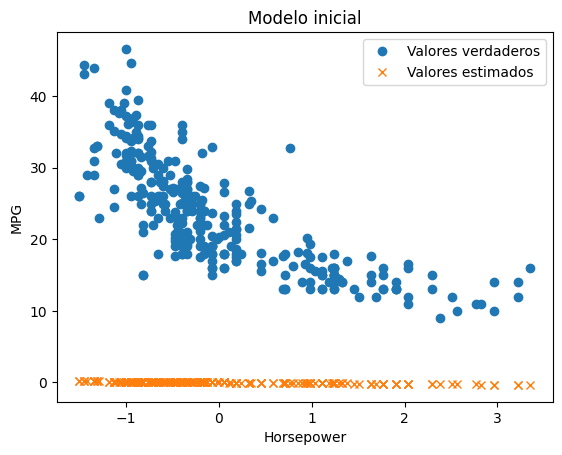

In [179]:
plot_regression(modelo1,x_train_transform,y_train,title=f"Modelo inicial",xlabel="Horsepower",ylabel="MPG")

In [180]:
# Entrenamiento del modelo
modelo1.fit(x_train_transform,
            y_train,
            epochs=100,
            batch_size=16,
            verbose=True)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 584.0804 - mae: 22.9756  
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 540.9219 - mae: 22.0749 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 501.0865 - mae: 21.2096 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 464.3182 - mae: 20.3783 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 430.3807 - mae: 19.5797 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 399.0558 - mae: 18.8124 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 370.1425 - mae: 18.0752 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 343.4547 - mae: 17.3670 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 318.8211 - mae: 16.6866 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 296.0835 - mae: 16.0330 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 275.0957 - mae: 15.4050 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 255.7230 - ma

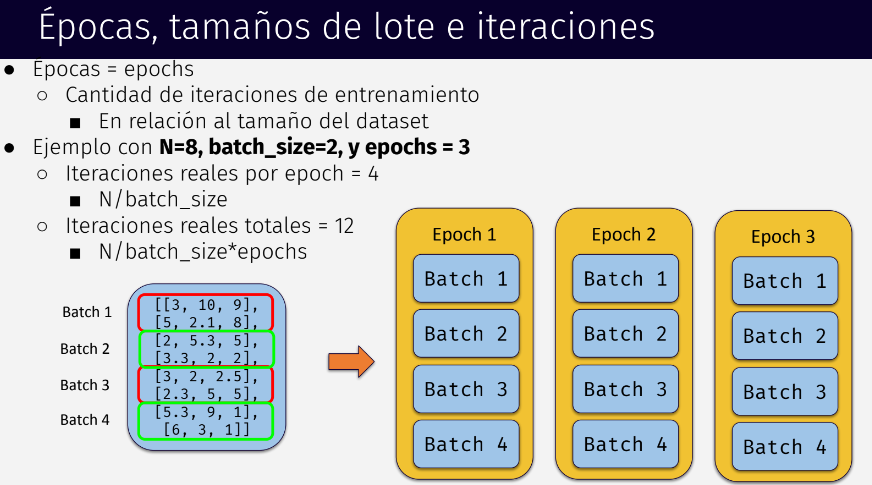

Este es el numero de veces que se ejecutaran los algoritmos de forwardpropagation y backpropagation. En cada ciclo (epoch) todos los datos de entrenamiento pasan por la red neuronal para que esta aprenda sobre ellos, si existen 10 ciclos y 1000 datos, cada ciclo los 1000 datos pasaran por la red neuronal. Si se especifica el parametro batch size cada ciclo (epoch) tendra más ejecuciones internas, estas ejecuciones se llaman iteraciones, si tenemos un batch size de 100, se tendran 10 iteraciones para completar un ciclo, en cada iteración se ejecutan los algoritmos de forwardpropagation y backpropagation, de esta manera la red neuronal actualiza más veces los parametros W (pesos) y b (bias).

Miremos como la red aprendio los datos con los que fue entrenada

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


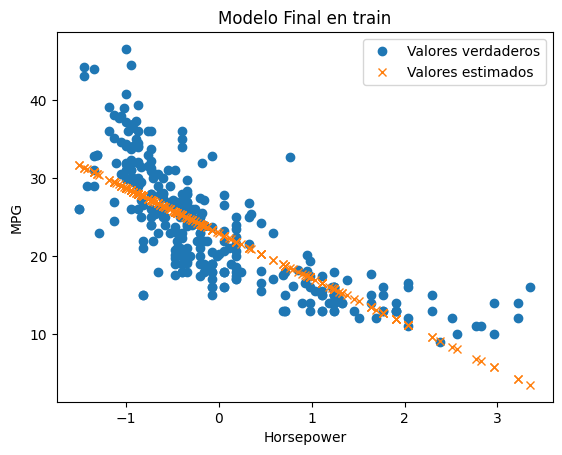

In [181]:
plot_regression(modelo1,x_train_transform,y_train,
                title=f"Modelo Final en train",xlabel="Horsepower",ylabel="MPG")

Miremos como la red predice en test

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


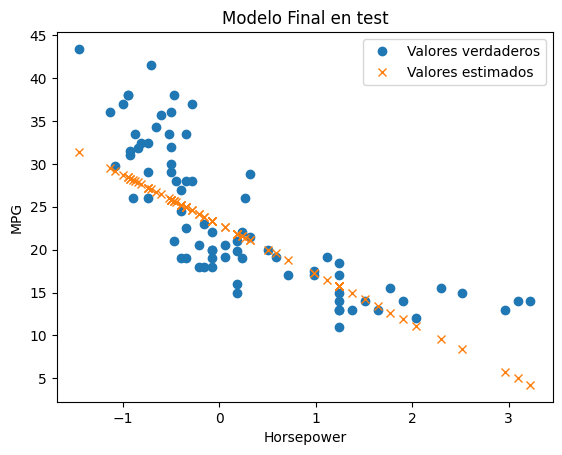

In [182]:
plot_regression(modelo1,x_test_transform,y_test,
                title=f"Modelo Final en test",xlabel="Horsepower",ylabel="MPG")

In [183]:
y_pred_modelo1=modelo1.predict(x_test_transform)

mae_modelo1=mean_absolute_error(y_test,y_pred_modelo1)
mse_modelo1=mean_squared_error(y_test,y_pred_modelo1)

print(f"Error absoluto medio {mae_modelo1}")
print(f"Error cuadrático medio {mse_modelo1}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Error absoluto medio 4.350662934025632
Error cuadrático medio 30.18450507994958


#### Modelo 2

Creamos el modelo

In [184]:
# Creo un modelo Red Neuronal
d_in=1
d_out=1

modelo2 = keras.Sequential([
    # input_shape solo en la primer capa
    # Capa con 2 salidas, activación relu
    keras.layers.Dense(2,input_shape=(d_in,), activation="relu"),
    # Capa con 2 salidas, activación tanh
    keras.layers.Dense(2, activation="tanh" ),
    keras.layers.Dense(d_out, )])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [185]:
modelo2.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [186]:
modelo2.compile(
  optimizer=keras.optimizers.SGD(learning_rate=0.001),
  loss='mse',
  # metricas para ir calculando en cada iteracion o batch
  metrics=['mae'],
)

In [187]:
# Entrenamiento del modelo
modelo2.fit(x_train_transform,y_train,epochs=100,batch_size=16,verbose=True)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 572.4761 - mae: 22.6120  
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 463.9329 - mae: 20.1144 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 379.4146 - mae: 17.8965 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 311.6397 - mae: 15.8934 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 257.8763 - mae: 14.1037 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 215.4497 - mae: 12.5303 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 182.0316 - mae: 11.1818 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 155.7279 - mae: 10.0768 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 135.0310 - mae: 9.2168 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 118.7482 - mae: 8.5515 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 105.9388 - mae: 8.0306 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 95.8616 - mae: 7

Verificamos cómo aprendio los datos de entrenamiento

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


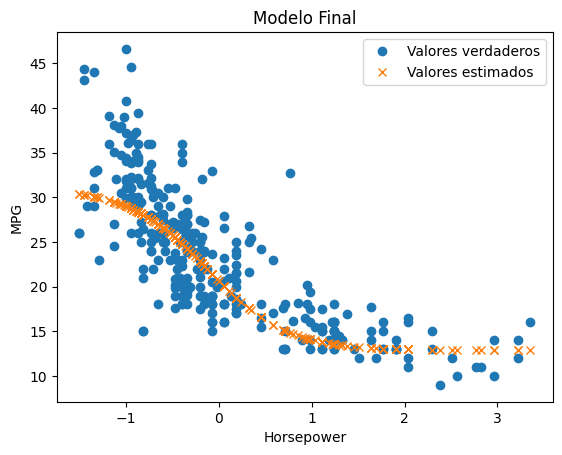

In [188]:
plot_regression(modelo2,x_train_transform,y_train,title=f"Modelo Final en train",xlabel="Horsepower",ylabel="MPG")

Evaluamos el modelo en el dataset de test

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


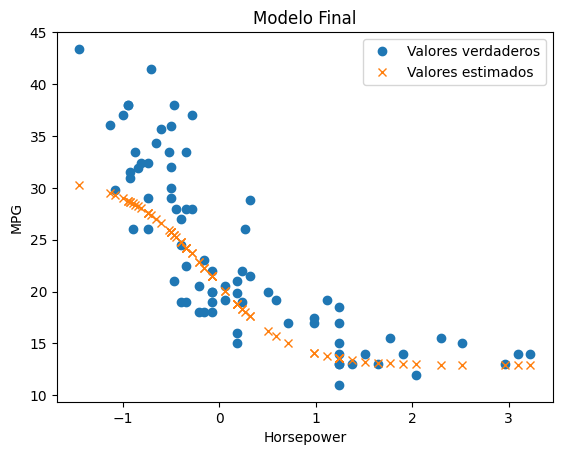

In [189]:
plot_regression(modelo2,x_test_transform,y_test,title=f"Modelo Final en test",xlabel="Horsepower",ylabel="MPG")

In [190]:
y_pred_2=modelo2.predict(x_test_transform)

mae=mean_absolute_error(y_test,y_pred_2)
mse=mean_squared_error(y_test,y_pred_2)

print(f"Error absoluto medio {mae}")
print(f"Error cuadrático medio {mse}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Error absoluto medio 3.93579914479316
Error cuadrático medio 27.044662721329427


### Modelo 3

In [191]:
from keras import initializers

# Creo un modelo Red Neuronal
d_in=1
d_out=1

modelo3 = keras.Sequential([
    # input_shape solo en la primer capa
    # Capa con 2 salidas, activación relu
    keras.layers.Dense(2,input_shape=(d_in,), activation="relu",kernel_initializer= initializers.RandomNormal(stddev=0.01)),
    # Capa con 2 salidas, activación tanh
    keras.layers.Dense(50, activation="relu" ),
    keras.layers.Dense(d_out, )])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [192]:
modelo3.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 50)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205 (820.00 B)

 Trainable params: 205 (820.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 578.7902 - mae: 22.8016  
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 480.3278 - mae: 20.5121 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 151.4948 - mae: 9.6603  
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 22.5391 - mae: 3.6412 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.7280 - mae: 3.5733 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.6018 - mae: 3.5638 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.5003 - mae: 3.5529 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.3714 - mae: 3.5375 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.2442 - mae: 3.5173 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.1205 - mae: 3.4985 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.9819 - mae: 3.4768 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.8435 - mae: 3.4585 
Epoch 

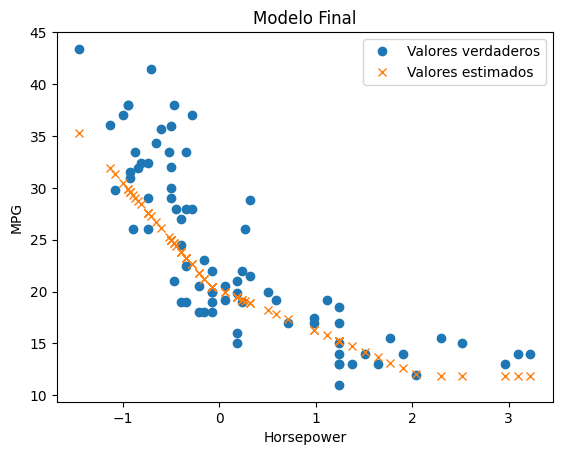

In [193]:
modelo3.compile(
  optimizer=keras.optimizers.SGD(learning_rate=0.001),
  loss='mse',
  # metricas para ir calculando en cada iteracion o batch
  metrics=['mae'],
)

modelo3.fit(x_train_transform,y_train,epochs=100,batch_size=16,verbose=True)

plot_regression(modelo3,x_test_transform,y_test,title=f"Modelo Final en test",xlabel="Horsepower",ylabel="MPG")

Comparamos con el modelo 2

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


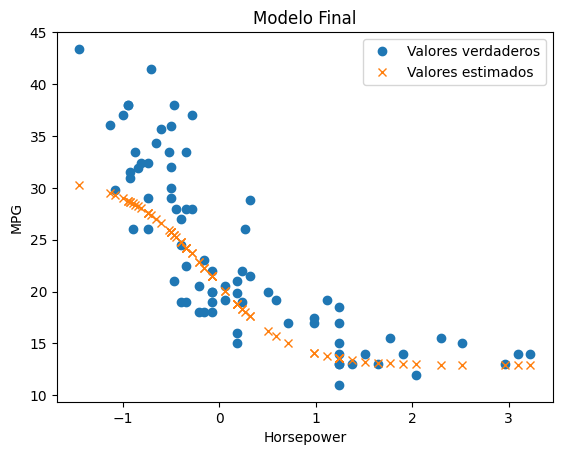

In [194]:
plot_regression(modelo2,x_test_transform,y_test,title=f"Modelo Final",xlabel="Horsepower",ylabel="MPG")

In [195]:
y_pred_3=modelo3.predict(x_test_transform)

mae=mean_absolute_error(y_test,y_pred_3)
mse=mean_squared_error(y_test,y_pred_3)

print(f"Error absoluto medio {mae}")
print(f"Error cuadrático medio {mse}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Error absoluto medio 3.6847082789940164
Error cuadrático medio 24.577692547337552
